You will need to identify a source or sources for each of the minerals in the 2022 List of Critical Minerals

You will need to categorize each source country as an ally, a competitor or a neutral party.

You will need to develop data visualizations that tell the story of source dependency and shortfall impact.

This assignment is due at the end of week fourteen of the semester

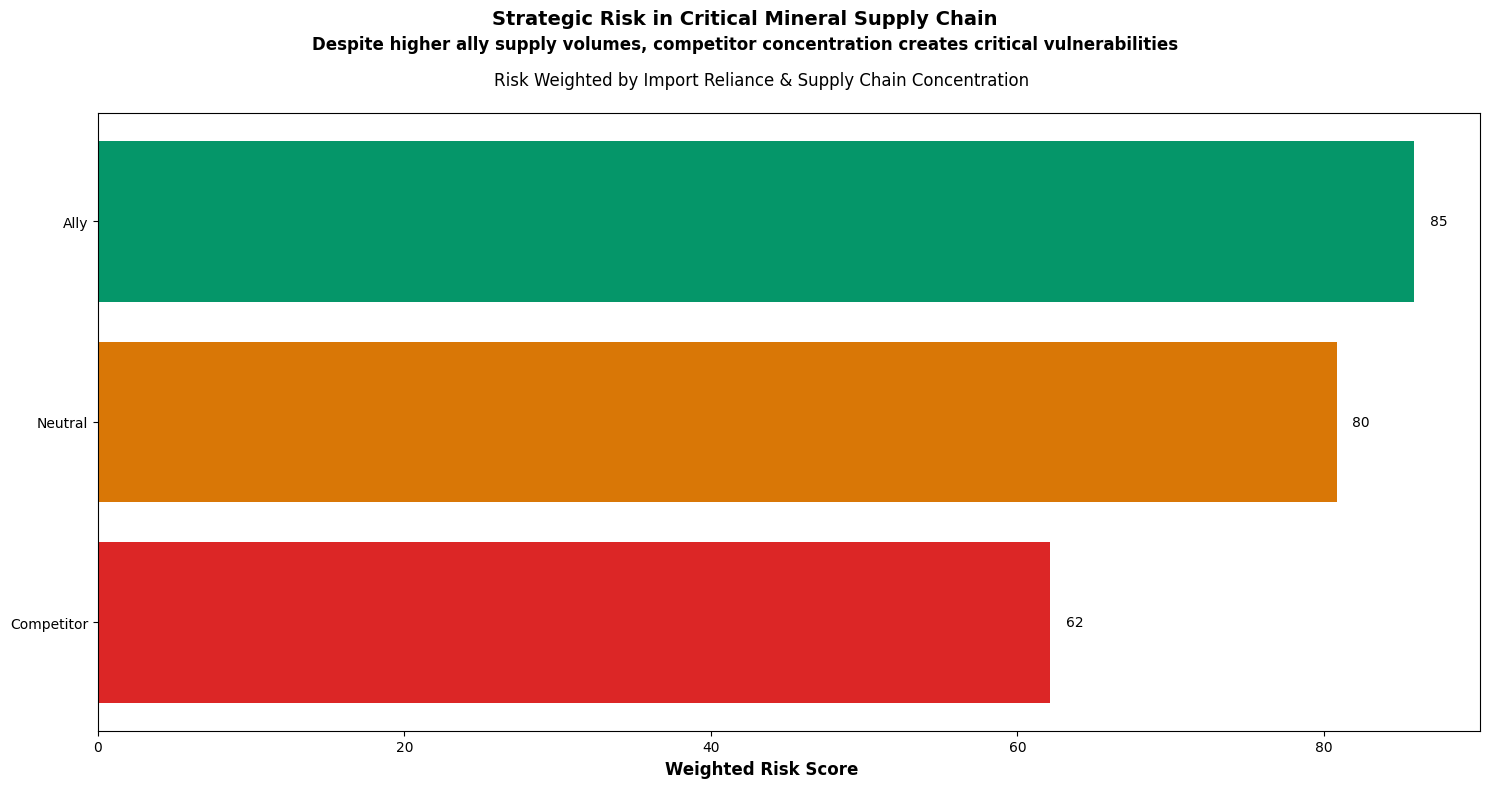

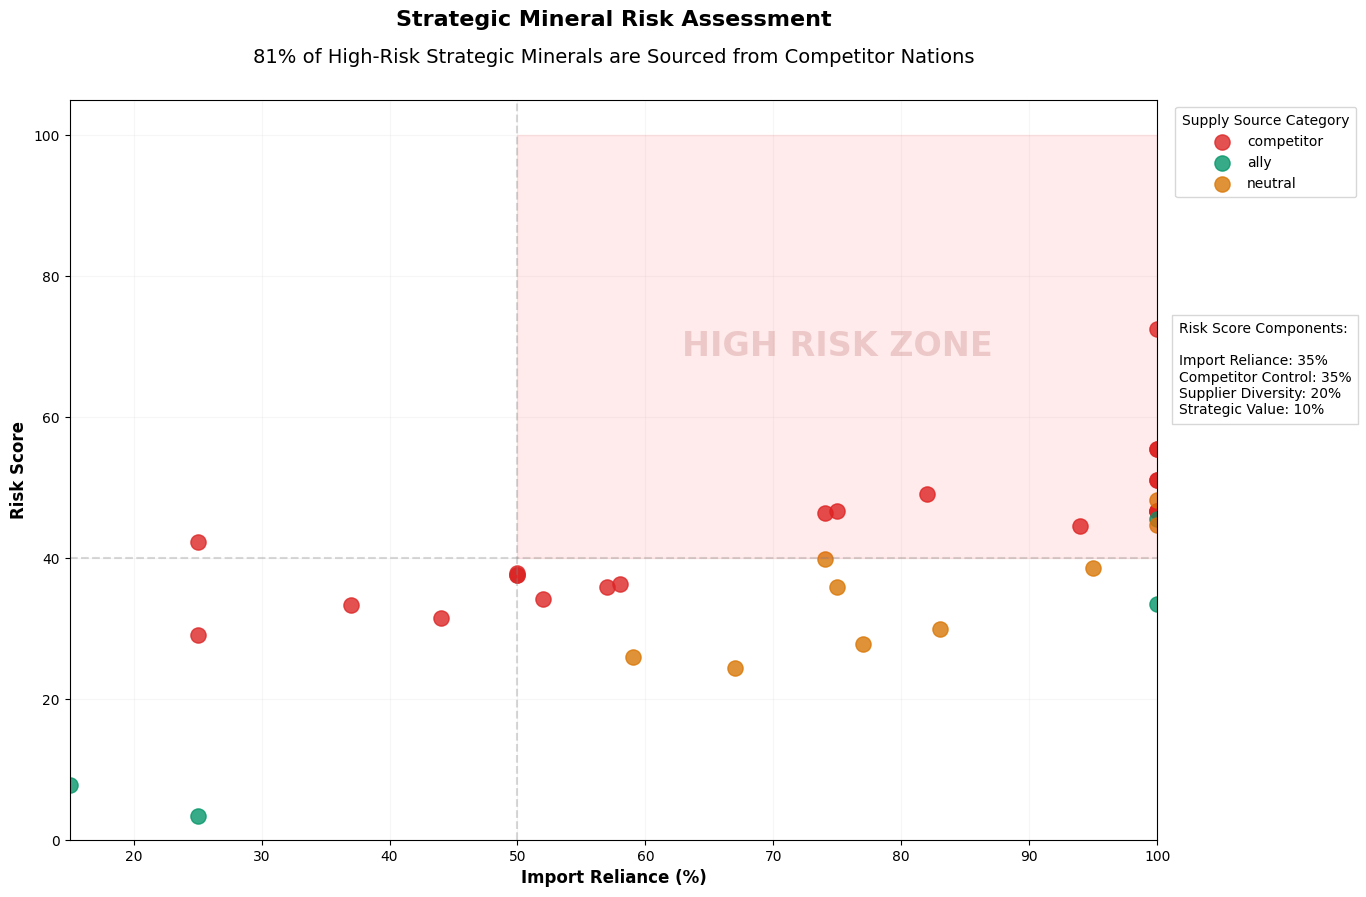

In [30]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

import scipy


def glimpse(df, df_name = "dataframe"):
    """
    Display DataFrame info similar to R's glimpse function
    """
    print("-" * 80)
    print(f"Dataframe: {df_name}")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print("\nColumn preview:")

    # For each column, show type and first few values
    for col in df.columns:
        # Get sample values but handle potential errors
        try:
            sample = df[col].head(5).tolist()
            # Truncate long strings
            sample = [str(x)[:50] + '...' if isinstance(x, str) and len(str(x)) > 50 else str(x) for x in sample]
            sample_str = ', '.join(sample)
        except (ValueError) as e:
            sample_str = f"Error getting samples: {str(e)}"
            
        # Print column info
        print(f"{col:<20} <{df[col].dtype}> {sample_str}")
    print("-" * 80)

def get_country_category():
    return {
        # Major Allies (NATO, Major Non-NATO Allies, Strategic Partners)
        'ally': [
            'Australia', 'Austria', 'Belgium', 'Canada', 'France', 'Germany', 
            'Israel', 'Japan', 'Mexico', 'Netherlands', 'Norway', 'Philippines', 
            'Republic of Korea', 'Switzerland', 'Taiwan', 'United Arab Emirates',
            'United Kingdom', 'Ukraine'
        ],
        # Strategic Competitors
        'competitor': [
            'China', 'Russia', 'Belarus', 'Iran', 'North Korea',
        ],
        # Others - neither close ally nor strategic competitor
        'neutral': [
            'Argentina', 'Bolivia', 'Brazil', 'Chile', 'Congo', 'Egypt', 'Estonia',
            'Finland', 'Gabon', 'Georgia', 'Greece', 'Guyana', 'India', 'Indonesia',
            'Ireland', 'Italy', 'Jamaica', 'Jordan', 'Kazakhstan', 'Madagascar',
            'Malaysia', 'Morocco', 'Peru', 'Poland', 'Saudi Arabia', 'Senegal',
            'South Africa', 'Turkey', 'Vietnam', 'Zimbabwe'
        ]
    }

def categorize_countries(countries, categories):
    """Categorize list of countries based on categories dict"""
    result = []
    for country in countries:
        if country in categories['ally']:
            result.append('ally')
        elif country in categories['competitor']:
            result.append('competitor')
        else:
            result.append('neutral')
    return result


# Add primary category (most concerning from strategic perspective)
def get_primary_category(categories):
    if 'competitor' in categories:
        return 'competitor'
    elif 'neutral' in categories:
        return 'neutral'
    return 'ally'


def standardize_material_name(name):
    """Standardize material names across all datasets"""
    name = str(name).lower().strip()
    
    # Handle parentheses and multiple forms
    name = name.replace('(natural)', '').replace('(industrial)', '')
    name = name.split('(')[0].strip()
    name = name.split(',')[0].strip()
    
    # Specific mappings
    replacements = {
        'columbium': 'niobium',
        'bauxite': 'aluminum',
        'alumina': 'aluminum',
        'platinum group metals': 'platinum',
        'titanium ilmenite': 'titanium',
        'rare earths': 'rare earth elements',
        'magnesium compounds': 'magnesium',
        'magnesium metal': 'magnesium',
        'coltan': 'niobium',
        'zirconium and hafnium': 'zirconium'
    }
    
    for old, new in replacements.items():
        if old in name:
            name = new
            
    return name.strip()

def get_usgs_critical_commodities_df():
    USGS_Critical_Commodities = \
    """Aluminum, used in almost all sectors of the economy
    Antimony, used in lead-acid batteries and flame retardants
    Arsenic, used in semi-conductors
    Barite, used in hydrocarbon production.
    Beryllium, used as an alloying agent in aerospace and defense industries
    Bismuth, used in medical and atomic research
    Cerium, used in catalytic converters, ceramics, glass, metallurgy, and polishing compounds
    Cesium, used in research and development
    Chromium, used primarily in stainless steel and other alloys
    Cobalt, used in rechargeable batteries and superalloys
    Dysprosium, used in permanent magnets, data storage devices, and lasers
    Erbium, used in fiber optics, optical amplifiers, lasers, and glass colorants
    Europium, used in phosphors and nuclear control rods
    Fluorspar, used in the manufacture of aluminum, cement, steel, gasoline, and fluorine chemicals
    Gadolinium, used in medical imaging, permanent magnets, and steelmaking
    Gallium, used for integrated circuits and optical devices like LEDs
    Germanium, used for fiber optics and night vision applications
    Graphite , used for lubricants, batteries, and fuel cells
    Hafnium, used for nuclear control rods, alloys, and high-temperature ceramics
    Holmium, used in permanent magnets, nuclear control rods, and lasers
    Indium, used in liquid crystal display screens
    Iridium, used as coating of anodes for electrochemical processes and as a chemical catalyst
    Lanthanum, used to produce catalysts, ceramics, glass, polishing compounds, metallurgy, and batteries
    Lithium, used for rechargeable batteries
    Lutetium, used in scintillators for medical imaging, electronics, and some cancer therapies
    Magnesium, used as an alloy and for reducing metals
    Manganese, used in steelmaking and batteries
    Neodymium, used in permanent magnets, rubber catalysts, and in medical and industrial lasers
    Nickel, used to make stainless steel, superalloys, and rechargeable batteries
    Niobium, used mostly in steel and superalloys
    Palladium, used in catalytic converters and as a catalyst agent
    Platinum, used in catalytic converters
    Praseodymium, used in permanent magnets, batteries, aerospace alloys, ceramics, and colorants
    Rhodium, used in catalytic converters, electrical components, and as a catalyst
    Rubidium, used for research and development in electronics
    Ruthenium, used as catalysts, as well as electrical contacts and chip resistors in computers
    Samarium, used in permanent magnets, as an absorber in nuclear reactors, and in cancer treatments
    Scandium, used for alloys, ceramics, and fuel cells
    Tantalum, used in electronic components, mostly capacitors and in superalloys
    Tellurium, used in solar cells, thermoelectric devices, and as alloying additive
    Terbium, used in permanent magnets, fiber optics, lasers, and solid-state devices
    Thulium, used in various metal alloys and in lasers
    Tin, used as protective coatings and alloys for steel
    Titanium, used as a white pigment or metal alloys
    Tungsten, primarily used to make wear-resistant metals
    Vanadium, primarily used as alloying agent for iron and steel
    Ytterbium, used for catalysts, scintillometers, lasers, and metallurgy
    Yttrium, used for ceramic, catalysts, lasers, metallurgy, and phosphors
    Zinc, primarily used in metallurgy to produce galvanized steel
    Zirconium, used in the high-temperature ceramics and corrosion-resistant alloys.
    """

    rows = [line.split(", ", 1) for line in USGS_Critical_Commodities.strip().split("\n")]
    df = pd.DataFrame(rows, columns=["Material", "info"])
    df['Material_std'] = df['Material'].apply(standardize_material_name)
    return df


def calculate_risk_score(row):
    """Calculate 0-100 risk score with enhanced differentiation"""
    reliance_weight = 0.35  # Slightly reduced from 0.4
    competitor_weight = 0.35  # Slightly reduced from 0.4
    diversity_weight = 0.2  # Kept the same
    strategic_weight = 0.1  # New factor
    
    # Count supplier types
    competitor_count = row['ImportCountry_Categories'].count('competitor')
    ally_count = row['ImportCountry_Categories'].count('ally')
    total_suppliers = len(row['ImportCountry_Categories'])
    
    # Enhanced competitor ratio - now considers both competitors and allies
    competitor_ratio = competitor_count / total_suppliers if total_suppliers > 0 else 0
    ally_ratio = ally_count / total_suppliers if total_suppliers > 0 else 0
    strategic_balance = competitor_ratio - (ally_ratio * 0.5)  # Allies provide some mitigation
    
    # More nuanced diversity score
    diversity_score = 1 - (min(total_suppliers, 5) / 5)  # Changed from 4 to 5 suppliers
    if total_suppliers == 1:  # Extra penalty for single-source
        diversity_score += 0.2
    
    # Strategic importance factor (based on primary supplier)
    strategic_factor = 1.0
    if row['Primary_Category'] == 'competitor':
        strategic_factor = 1.2
    elif row['Primary_Category'] == 'ally':
        strategic_factor = 0.8
    
    # Calculate combined score with more factors
    risk_score = (
        (row['Import_Reliance_Pct'] / 100 * reliance_weight) +
        (strategic_balance * competitor_weight) +
        (diversity_score * diversity_weight) +
        (strategic_factor * strategic_weight)
    ) * 100
    
    return round(risk_score, 1)

def get_mineral_commodity_summary():
    # Define rare earth elements
    rare_earths = [
        "cerium", "dysprosium", "erbium", "europium", "gadolinium", "holmium", 
        "lanthanum", "lutetium", "neodymium", "praseodymium", "samarium", "terbium", 
        "thulium", "ytterbium"
    ]

    mcs = {
        "Material": [
            # Original list from chart
            "Arsenic, all forms", "Asbestos", "Cesium", "Fluorspar", "Gallium", "Graphite (Natural)",
            "Indium", "Manganese", "Mica (Natural), sheet", "Niobium (Columbium)", "Rubidium",
            "Scandium", "Strontium", "Tantalum", "Yttrium", "Gemstones", 
            "Abrasives, fused aluminum oxide", "Nepheline Syenite", "Rare Earths", 
            "Titanium, sponge metal", "Bismuth", "Potash", "Stone (Dimension)", 
            "Diamond (Industrial), stones", "Platinum", "Antimony, metal and oxide", 
            "Zinc, refined", "Barite", "Bauxite", "Iron Oxide Pigments, natural and synthetic",
            "Titanium Mineral Concentrates", "Chromium, all forms", "Peat", "Tin, refined",
            "Abrasives, silicon carbide", "Silver", "Cobalt", "Garnet (Industrial)",
            "Rhenium", "Alumina", "Vanadium", "Nickel", "Diamond (Industrial), bort, grit, and dust and powder",
            "Magnesium Compounds", "Germanium", "Iodine", "Magnesium Metal", "Selenium",
            "Tungsten", "Silicon, metal and ferrosilicon", "Copper, refined", "Aluminum",
            "Palladium", "Lead, refined", "Mica (Natural), scrap and flake", "Perlite",
            "Lithium", "Tellurium", "Salt", "Bromine", "Zirconium, ores and concentrates",
            "Cement", "Vermiculite",
            # Adding Lanthanides
            "Cerium", "Dysprosium", "Erbium", "Europium", "Gadolinium", "Holmium", 
            "Lanthanum", "Lutetium", "Neodymium", "Praseodymium", "Samarium", "Terbium", 
            "Thulium", "Ytterbium",
            # Adding low import reliance materials
            "Beryllium", "Boron", "Cadmium", "Diatomite", "Gold", "Iron and Steel", 
            "Molybdenum", "Titanium Dioxide", "Zeolites"
        ],
        "Import_Reliance_Pct": [
            # Original percentages
            100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 99, 
            95, 95, 95, 95, 94, 91, 87, 84, 83, 82, 77, 75, 75, 75, 75, 74, 74, 74, 73, 69,
            67, 67, 60, 59, 58, 57, 56, 52, 50, 50, 50, 50, 50, 50, 46, 44, 37, 35, 28, 26,
            25, 25, 25, 25, 25, 22, 20,
            # Lanthanides (included in Rare Earths at 95%)
            95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95,
            # Low import reliance materials (<20%)
            15, 15, 15, 15, 15, 15, 15, 15, 15
        ],
        "ImportCountries": [
            ["China", "Morocco", "Malaysia", "Belgium"], 
            ["Brazil", "Russia"],
            ["Germany"],
            ["Mexico", "Vietnam", "China", "South Africa"],
            ["Japan", "China", "Germany", "Canada"],
            ["China", "Mexico", "Canada", "Madagascar"],
            ["Republic of Korea", "Canada", "Belgium"],
            ["Gabon", "South Africa", "Australia", "Georgia"],
            ["China", "Brazil", "India", "Belgium"],
            ["Brazil", "Canada"],
            ["China", "Germany", "Russia"],
            ["Japan", "China", "Germany", "Philippines"],
            ["Mexico", "Germany", "China"],
            ["China", "Germany", "Australia", "Indonesia"],
            ["China", "Germany", "France", "Republic of Korea"],
            ["India", "Israel", "Belgium", "South Africa"],
            ["China", "Canada", "Brazil", "Austria"],
            ["Canada"],
            ["China", "Malaysia", "Japan", "Estonia"],
            ["Japan", "Kazakhstan", "Saudi Arabia", "Ukraine"],
            ["China", "Republic of Korea", "Belgium", "Mexico"],
            ["Canada", "Russia", "Belarus"],
            ["Brazil", "China", "Italy", "Turkey"],
            ["India", "South Africa", "Russia", "Congo (Kinshasa)"],
            ["South Africa", "Switzerland", "Germany", "Belgium"],
            ["China", "Belgium", "India", "Bolivia"],
            ["Canada", "Mexico", "Peru", "Republic of Korea"],
            ["India", "China", "Morocco", "Mexico"],
            ["Jamaica", "Turkey", "Guyana", "Australia"],
            ["China", "Germany", "Brazil", "Canada"],
            ["South Africa", "Madagascar", "Australia", "Canada"],
            ["South Africa", "Kazakhstan", "Russia", "Canada"],
            ["Canada"],
            ["Peru", "Bolivia", "Indonesia", "Malaysia"],
            ["China", "Brazil", "Canada", "Netherlands"],
            ["Mexico", "Canada", "Poland", "Switzerland"],
            ["Norway", "Canada", "Finland", "Japan"],
            ["South Africa", "Australia", "China", "India"],
            ["Chile", "Canada", "Germany", "Kazakhstan"],
            ["Brazil", "Australia", "Jamaica", "Canada"],
            ["Canada", "Brazil", "Austria", "Russia"],
            ["Canada", "Norway", "Finland", "Russia"],
            ["China", "Republic of Korea", "Ireland", "Russia"],
            ["China", "Israel", "Canada", "Brazil"],
            ["Belgium", "China", "Canada"],
            ["Chile", "Japan"],
            ["China", "Israel", "Taiwan"],
            ["Philippines", "Mexico", "Germany", "Canada"],
            ["China", "Germany", "Bolivia", "Vietnam"],
            ["Brazil", "Russia", "Canada", "Norway"],
            ["Chile", "Canada", "Mexico"],
            ["Canada", "United Arab Emirates", "Bahrain", "Russia"],
            ["Russia", "South Africa", "Italy", "Canada"],
            ["Canada", "Mexico", "Republic of Korea", "Australia"],
            ["China", "Canada", "India", "Finland"],
            ["Greece", "China", "Mexico"],
            ["Argentina", "Chile", "China", "Russia"],
            ["Canada", "Germany", "Philippines", "Japan"],
            ["Canada", "Chile", "Mexico", "Egypt"],
            ["Israel", "Jordan", "China"],
            ["South Africa", "Australia", "Senegal", "Russia"],
            ["Turkey", "Canada", "Greece", "Mexico"],
            ["South Africa", "Brazil", "Zimbabwe"],
            # Lanthanides (using same sources as Rare Earths)
            *[["China", "Malaysia", "Japan", "Estonia"] for _ in range(14)],
            # Low import reliance materials (example sources)
            ["Canada", "Mexico"], ["Turkey", "Chile"], ["South Korea", "Mexico"],
            ["Mexico", "China"], ["Canada", "Mexico"], ["Canada", "Brazil"],
            ["Chile", "Peru"], ["South Africa", "Australia"], ["Turkey", "South Africa"]
        ]
    }
    
    df = pd.DataFrame(mcs)
    
    df['Material_std'] = df['Material'].apply(standardize_material_name)
    
    rare_earth_mask = df['Material_std'].isin(rare_earths)
    if rare_earth_mask.any():
        rare_earth_row = df[rare_earth_mask].iloc[0].copy()
        rare_earth_row['Material'] = "Rare Earth Metals"
        rare_earth_row['Material_std'] = "rare earth metals"
        
        # Remove individual rare earth rows and add composite row
        df = df[~rare_earth_mask]
        df = pd.concat([df, pd.DataFrame([rare_earth_row])], ignore_index=True)
    
    return df

def enhance_mineral_commodity_summary(df):
    """Add strategic risk analysis to mineral commodity summary"""
    # Get country categories
    categories = get_country_category()
    
    # Add country categorizations and risk metrics
    df = df.assign(
        ImportCountry_Categories=df['ImportCountries'].apply(lambda x: categorize_countries(x, categories)),
        Primary_Category=df['ImportCountries'].apply(lambda x: get_primary_category(categorize_countries(x, categories))),
        Competitor_Suppliers=df['ImportCountries'].apply(lambda x: categorize_countries(x, categories).count('competitor')),
    )
    
    # Calculate overall risk score
    df['Risk_Score'] = df.apply(calculate_risk_score, axis=1)
    
    return df


#def plot_strategic_minerals(critical_df, mcs_df):
    """
    Create scatter plot with improved organization and legend placement
    """
    plt.figure(figsize=(15, 10))
    
    # Define colors and symbols map
    colors = {
        'competitor': '#dc2626',
        'ally': '#059669',
        'neutral': '#d97706'
    }
    
    symbol_map = {
        'rubidium': 'Rb',
        'cesium': 'Cs',
        'scandium': 'Sc',
        'yttrium': 'Y',
        'gallium': 'Ga',
        'tantalum': 'Ta',
        'niobium': 'Nb',
        'arsenic': 'As',
        'rare earth metals': 'REE'  # Added unified symbol for rare earths
    }
    
    # Filter and prepare data
    minerals = mcs_df[mcs_df['Material_std'].isin(critical_df['Material_std'])]
    high_risk = minerals[minerals['Risk_Score'] > 40]
    competitor_high_risk = high_risk[high_risk['Primary_Category'] == 'competitor']
    competitor_percent = len(competitor_high_risk) / len(high_risk) * 100
    
    # Get top 10 materials
    top_10_materials = set(minerals.nlargest(10, 'Risk_Score')['Material_std'])
    
    # Create scatter plot
    for category in colors:
        mask = minerals['Primary_Category'] == category
        plt.scatter(
            minerals[mask]['Import_Reliance_Pct'],
            minerals[mask]['Risk_Score'],
            c=colors[category],
            label=category,
            alpha=0.8,
            s=120
        )
    
    # Add labels for top 10 materials with offset to prevent overlap
    offset_x = 2
    offset_y = 2
    
    for _, point in minerals[minerals['Material_std'].isin(top_10_materials)].iterrows():
        label = symbol_map.get(point['Material_std'], point['Material_std'])
        plt.annotate(
            label,
            xy=(point['Import_Reliance_Pct'], point['Risk_Score']),
            xytext=(point['Import_Reliance_Pct'] + offset_x, point['Risk_Score'] + offset_y),
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7),
            arrowprops=dict(
                arrowstyle='->',
                color='gray',
                lw=0.5
            ),
            fontsize=10
        )
    
    # Add grid lines and risk quadrant
    plt.axhline(y=40, color='gray', linestyle='--', alpha=0.3)
    plt.axvline(x=50, color='gray', linestyle='--', alpha=0.3)
    plt.fill_between([50, 100], 40, 100, alpha=0.08, color='red')
    
    # Set axis limits and labels
    plt.xlim(15, 105)
    plt.ylim(0, 105)
    plt.xlabel('Import Reliance (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Risk Score', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.1)
    
    # Create legend and annotations
    legend = plt.legend(
        title='Supply Source Category',
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=True
    )
    legend.get_frame().set_alpha(0.9)
    
    # Add symbol key for elements in top 10
    symbol_key = '\n'.join([f'{v} = {k.title()}' 
                           for k, v in symbol_map.items() 
                           if k in top_10_materials])
    plt.text(1.05, 0.7,
            'Element Symbols:\n' + symbol_key,
            transform=plt.gca().transAxes,
            ha='left',
            va='top',
            fontsize=10,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9))
    
    # Add note about labeling
    plt.text(1.05, 0.45,
            'Note: Only top 10 highest-risk\nmaterials are labeled',
            transform=plt.gca().transAxes,
            ha='left',
            va='top',
            fontsize=10)
    
    # Add title with competitor percentage
    plt.suptitle(
        'Strategic Mineral Risk Assessment\n' +
        f'{competitor_percent:.0f}% of High-Risk Strategic Minerals are Sourced from Competitors',
        fontsize=14,
        y=0.95,
        ha='center'
    )
    
    plt.tight_layout()
    return plt.gcf()
def load_data():
   critical_df = get_usgs_critical_commodities_df()
   mcs_df = enhance_mineral_commodity_summary(get_mineral_commodity_summary())
   return critical_df, mcs_df



def plot_enhanced_strategic_minerals(critical_df, mcs_df):
    plt.figure(figsize=(15, 10))
    
    colors = {
        'competitor': '#dc2626',
        'ally': '#059669',
        'neutral': '#d97706'
    }
    
    # Filter and prepare data
    minerals = mcs_df[mcs_df['Material_std'].isin(critical_df['Material_std'])]
    high_risk = minerals[minerals['Risk_Score'] > 40]
    competitor_high_risk = high_risk[high_risk['Primary_Category'] == 'competitor']
    competitor_percent = len(competitor_high_risk) / len(high_risk) * 100
    
    # Create scatter plot
    for category in colors:
        mask = minerals['Primary_Category'] == category
        plt.scatter(
            minerals[mask]['Import_Reliance_Pct'],
            minerals[mask]['Risk_Score'],
            c=colors[category],
            label=category,
            alpha=0.8,
            s=120
        )
    
    # Add grid lines and risk quadrant
    plt.axhline(y=40, color='gray', linestyle='--', alpha=0.3)
    plt.axvline(x=50, color='gray', linestyle='--', alpha=0.3)
    plt.fill_between([50, 100], 40, 100, alpha=0.08, color='red')
    
    # Add "High Risk Zone" text in shaded area
    plt.text(75, 70, 'HIGH RISK ZONE', 
            color='darkred', alpha=0.15, fontsize=24, fontweight='bold',
            rotation=0, ha='center', va='center')
    
    # Set axis limits and labels
    plt.xlim(15, 100)
    plt.ylim(0, 105)
    plt.xlabel('Import Reliance (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Risk Score', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.1)
    
    # Create legend with specific styling
    legend = plt.legend(
        title='Supply Source Category',
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        frameon=True,
        borderpad=0.5,
        borderaxespad=0.5
    )
    legend.get_frame().set_alpha(0.9)
    legend.get_frame().set_edgecolor('#D3D3D3')
    
    # Add risk score explanation box with matching style
    props = dict(
        boxstyle='square',
        facecolor='white',
        alpha=0.9,
        edgecolor='#D3D3D3',
        pad=0.5
    )
    
    # Adjusted x-position to 1.02 to match legend alignment
    plt.text(1.02, 0.7,
            'Risk Score Components:\n\n' +
            'Import Reliance: 35%\n' +
            'Competitor Control: 35%\n' +
            'Supplier Diversity: 20%\n' +
            'Strategic Value: 10%',
            transform=plt.gca().transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=props)
    
    # Add titles
    plt.text(0.5, 1.1, 'Strategic Mineral Risk Assessment',
            transform=plt.gca().transAxes,
            fontsize=16, fontweight='bold', ha='center')
    
    plt.text(0.5, 1.05,
            f'{competitor_percent:.0f}% of High-Risk Strategic Minerals are Sourced from Competitor Nations',
            transform=plt.gca().transAxes,
            fontsize=14, ha='center')
    
    # Adjust layout to ensure everything fits
    plt.subplots_adjust(top=0.85, right=0.85)
    
    return plt.gcf()

def plot_supplier_analysis(mcs_df):
    """Create bar chart of critical mineral suppliers"""
    
    # Process data to get supplier counts
    all_suppliers = []
    for suppliers in mcs_df['ImportCountries']:
        all_suppliers.extend(suppliers)
    
    # Count unique materials per supplier
    supplier_counts = pd.Series(all_suppliers).value_counts()
    top_suppliers = supplier_counts.head(10)
    
    # Get categories for each supplier
    categories = get_country_category()
    supplier_categories = []
    for country in top_suppliers.index:
        if country in categories['competitor']:
            supplier_categories.append('competitor')
        elif country in categories['ally']:
            supplier_categories.append('ally')
        else:
            supplier_categories.append('neutral')
    
    # Create color map
    colors = {
        'competitor': '#dc2626',
        'ally': '#059669',
        'neutral': '#d97706'
    }
    bar_colors = [colors[cat] for cat in supplier_categories]
    
    # Create figure
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(top_suppliers)), top_suppliers.values, color=bar_colors)
    
    # Customize the plot
    plt.title('Top 10 Critical Mineral Suppliers\nColored by Strategic Category', 
              fontsize=14, pad=20)
    plt.xlabel('Supplier Country', fontsize=12)
    plt.ylabel('Number of Critical Minerals Supplied', fontsize=12)
    plt.xticks(range(len(top_suppliers)), top_suppliers.index, rotation=45, ha='right')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[cat], label=cat.title())
                      for cat in colors.keys()]
    plt.legend(handles=legend_elements, title='Strategic Category')
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    return plt.gcf()


# glimpse(critical_df)
# glimpse(mcs_df)


def plot_strategic_dependency(mcs_df):
    """Create bar chart showing strategic dependencies"""
    # Count all supply relationships by category
    all_relationships = []
    for idx, row in mcs_df.iterrows():
        all_relationships.extend(row['ImportCountry_Categories'])
    
    # Get total counts by category
    relationship_counts = pd.Series(all_relationships).value_counts()
    
    # Create color map
    colors = {
        'competitor': '#dc2626',
        'ally': '#059669',
        'neutral': '#d97706'
    }
    
    bar_colors = [colors[cat] for cat in relationship_counts.index]
    
    # Create figure
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(relationship_counts)), relationship_counts.values, color=bar_colors)
    
    # Calculate percentages for labels
    total = relationship_counts.sum()
    percentages = (relationship_counts / total * 100).round(1)
    
    # Customize the plot
    plt.title('Strategic Distribution of Critical Mineral Supply Relationships', 
              fontsize=14, pad=20)
    plt.ylabel('Number of Supply Relationships', fontsize=12)
    
    # Add percentage labels on top of bars
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({pct}%)',
                ha='center', va='bottom')
    
    plt.xticks(range(len(relationship_counts)), 
               [cat.title() for cat in relationship_counts.index], 
               rotation=0)
    
    plt.tight_layout()
    return plt.gcf()

def plot_weighted_strategic_risk_styled(mcs_df):
    """Create styled bar chart showing absolute weighted strategic risks"""
    # Initialize weighted counts for each category
    weighted_risk = {'competitor': 0, 'ally': 0, 'neutral': 0}
    
    # Calculate weighted risk for each material
    for _, row in mcs_df.iterrows():
        reliance = row['Import_Reliance_Pct'] / 100
        for category, count in pd.Series(row['ImportCountry_Categories']).value_counts().items():
            if category == row['Primary_Category']:
                weight = 2
            else:
                weight = 1
            weighted_risk[category] += reliance * weight * count
    
    # Convert to DataFrame for plotting
    risk_df = pd.DataFrame({
        'Category': weighted_risk.keys(),
        'Weighted_Risk': weighted_risk.values()
    })
    
    # Sort by weighted risk
    risk_df = risk_df.sort_values('Weighted_Risk', ascending=True)
    
    # Create figure with subplot, but make the actual chart smaller
    fig, ax = plt.subplots(figsize=(15, 8))  # reduced height from 10 to 8
    
    # Color mapping matching scatter plot
    colors = {
        'competitor': '#dc2626',
        'ally': '#059669',
        'neutral': '#d97706'
    }
    
    bars = ax.barh(range(len(risk_df)), risk_df['Weighted_Risk'],
                   color=[colors[cat] for cat in risk_df['Category']])
    
    # Customize the plot with centered titles
    fig.suptitle('Strategic Risk in Critical Mineral Supply Chain',
                 fontsize=14, fontweight='bold',  x=0.5)
    ax.set_title('Risk Weighted by Import Reliance & Supply Chain Concentration',
                fontsize=12, pad=20, ha='center', position=(0.48, 0))
    
    # Add the new "bumper sticker" text above the chart
    plt.figtext(0.5, 0.93,
               'Despite higher ally supply volumes, competitor concentration creates critical vulnerabilities',
               fontsize=12, ha='center', fontweight='bold')
    
    ax.set_xlabel('Weighted Risk Score', fontsize=12, fontweight='bold', ha='center', position=(0.48, 0))
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 1, i, f'{int(width)}',
                va='center')
    
    ax.set_yticks(range(len(risk_df)))
    ax.set_yticklabels([cat.title() for cat in risk_df['Category']])
    
    # Add border to the plot
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    
    plt.tight_layout()
    # Adjust the layout to make room for the new text
    plt.subplots_adjust(top=0.85)
    
    return fig


critical_df, mcs_df = load_data()

plt5 = plot_weighted_strategic_risk_styled(mcs_df)
plt.show()

#plt4 = plot_strategic_dependency(mcs_df)
#plt.show()

plot_enhanced_strategic_minerals(critical_df, mcs_df)
plt.show()

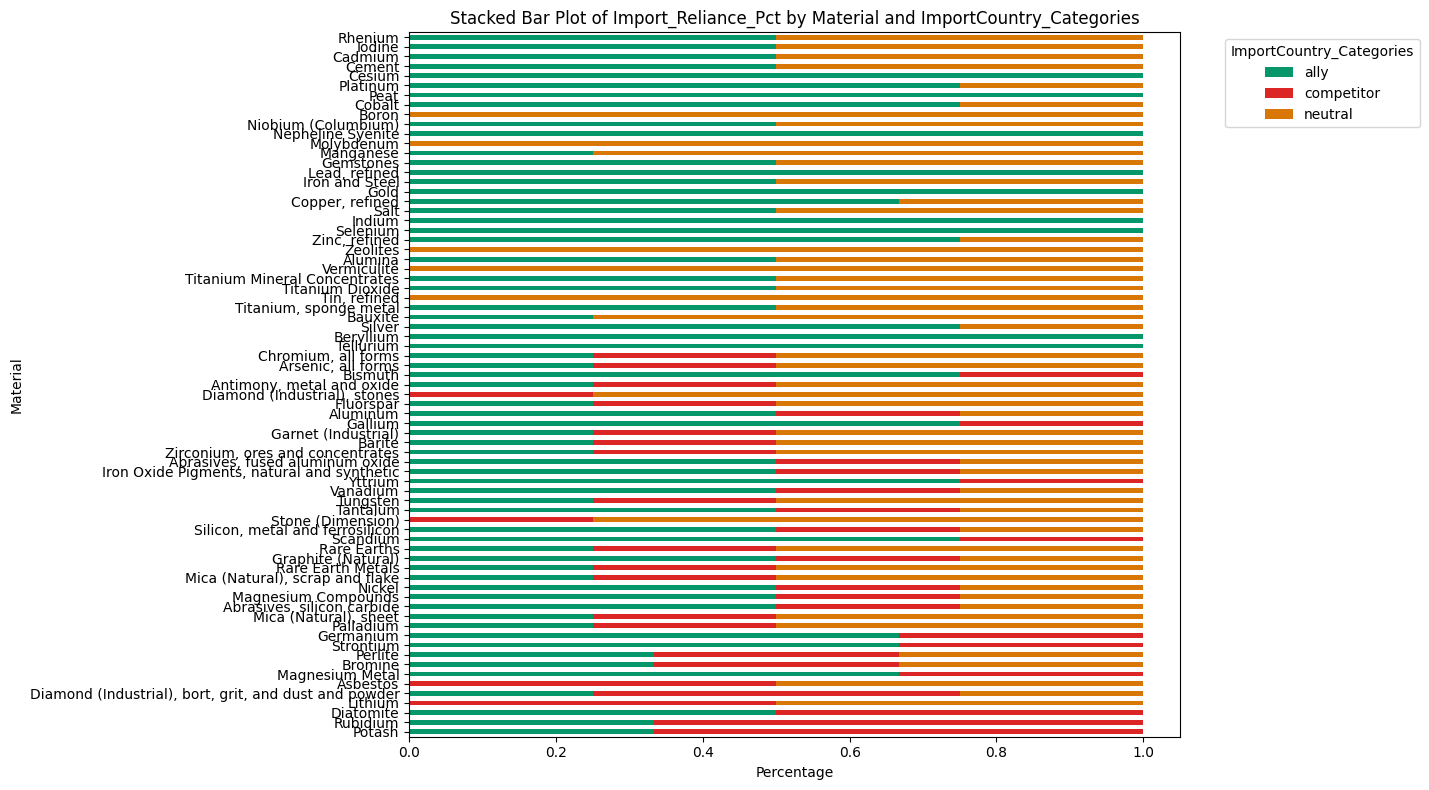

In [ ]:
def plot_stacked_barplot(data, commodity_column='Material', category_column='ImportCountry_Categories', value_column='Import_Reliance_Pct'):
    # Split the ImportCountry_Categories into separate rows
    exploded_data = data.assign(**{category_column: data[category_column].str.split(', ')}).explode(category_column)
    
    # Ensure the data is grouped by material and category, summing the values
    stacked_data = exploded_data.groupby([commodity_column, category_column])[value_column].sum().unstack(fill_value=0)
    
    # Normalize the data to get percentages
    stacked_data_pct = stacked_data.div(stacked_data.sum(axis=1), axis=0)
    
    # Sort by greatest percentage of competitor
    if 'competitor' in stacked_data_pct.columns:
        stacked_data_pct = stacked_data_pct.sort_values(by='competitor', ascending=False)
    
    # Define custom colors
    color_mapping = {
        'competitor': '#dc2626',  # Red
        'ally': '#059669',        # Green
        'neutral': '#d97706'      # Orange
    }
    
    # Get color list based on columns
    colors = [color_mapping.get(x, '#333333') for x in stacked_data_pct.columns]

    # Plot the stacked bar plot
    ax = stacked_data_pct.plot(kind='barh', stacked=True, figsize=(12, 8), color=colors)

    # Add titles and labels
    ax.set_title(f"Stacked Bar Plot of {value_column} by {commodity_column} and {category_column}")
    ax.set_xlabel("Percentage")
    ax.set_ylabel(commodity_column)
    
    # Adjust layout and add legend
    plt.tight_layout()
    plt.legend(title=category_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Show the plot
    plt.show()

plot_stacked_barplot(mcs_df)


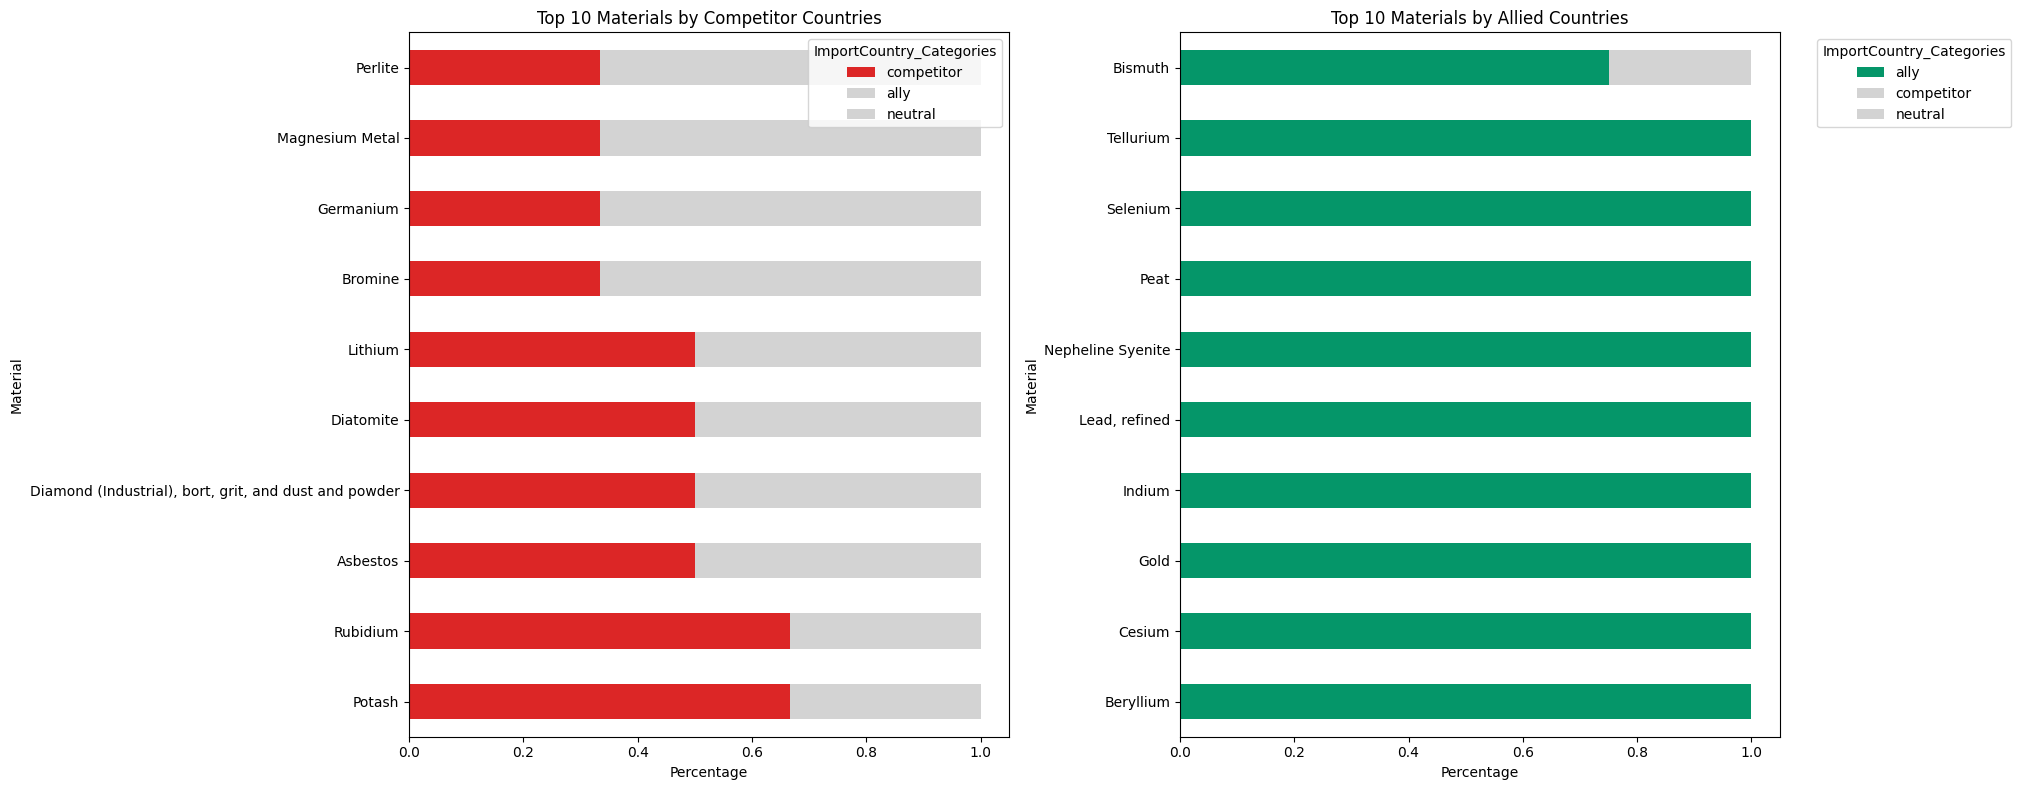

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_categories(data, commodity_column='Material', category_column='ImportCountry_Categories', value_column='Import_Reliance_Pct'):
    # Split the ImportCountry_Categories into separate rows
    exploded_data = data.assign(**{category_column: data[category_column].str.split(', ')}).explode(category_column)
    
    # Ensure the data is grouped by material and category, summing the values
    stacked_data = exploded_data.groupby([commodity_column, category_column])[value_column].sum().unstack(fill_value=0)
    
    # Normalize the data to get percentages
    stacked_data_pct = stacked_data.div(stacked_data.sum(axis=1), axis=0)
    
    # Top 10 by ally and competitor
    top_allies = stacked_data_pct.nlargest(10, 'ally')
    top_competitors = stacked_data_pct.nlargest(10, 'competitor')
    
    # Define custom colors
    color_mapping = {
        'competitor': '#dc2626',  # Red
        'ally': '#059669',        # Green
        'neutral': '#d3d3d3'      # Gray
    }

    # Create a color list for each category
    def create_color_list(data, highlight_category):
        return [color_mapping[highlight_category] if col == highlight_category else color_mapping['neutral'] for col in data.columns]

    # Sort by highlighted section (competitor or ally)
    def sort_by_highlighted_section(data, highlight_category):
        sorted_data = data.sort_values(by=highlight_category, ascending=False)
        return sorted_data

    # Reorder columns for stacking the bars
    def reorder_columns_for_stack(data, highlight_category):
        # Columns should be in the order of 'highlight_category' first, then others
        other_columns = [col for col in data.columns if col != highlight_category]
        return [highlight_category] + other_columns

    # Setup the figure (with sharey=False to handle y-ticks independently)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8), sharey=False)

    # Sort by competitor (red section first)
    sorted_competitors = sort_by_highlighted_section(top_competitors, 'competitor')
    ordered_competitors = sorted_competitors[reorder_columns_for_stack(sorted_competitors, 'competitor')]
    colors_competitors = create_color_list(ordered_competitors, 'competitor')
    ordered_competitors.plot(kind='barh', stacked=True, ax=axes[0], color=colors_competitors)
    axes[0].set_title("Top 10 Materials by Competitor Countries")
    axes[0].set_xlabel("Percentage")
    axes[0].set_ylabel(commodity_column)
    axes[0].set_yticks(range(len(ordered_competitors.index)))  # Set numeric tick locations
    axes[0].set_yticklabels(ordered_competitors.index)  # Set the actual commodity names

    # Sort by ally (green section first)
    sorted_allies = sort_by_highlighted_section(top_allies, 'ally')
    ordered_allies = sorted_allies[reorder_columns_for_stack(sorted_allies, 'ally')]
    colors_allies = create_color_list(ordered_allies, 'ally')
    ordered_allies.plot(kind='barh', stacked=True, ax=axes[1], color=colors_allies)
    axes[1].set_title("Top 10 Materials by Allied Countries")
    axes[1].set_xlabel("Percentage")
    axes[1].set_ylabel(commodity_column)  # Explicitly set the y-axis label for the right plot
    axes[1].set_yticks(range(len(ordered_allies.index)))  # Set numeric tick locations
    axes[1].set_yticklabels(ordered_allies.index)  # Set the actual commodity names

    # Adjust layout and add legend
    plt.tight_layout()  # This should ensure no overlap in labels
    plt.legend(title=category_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Show the plots
    plt.show()

# Call the function with your DataFrame
plot_top_categories(mcs_df)
